In [2]:
import pandas as pd

songs = pd.read_csv("songs_new.csv")

### Gaussian Mixture Model

In [3]:
import pandas as pd
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.metrics.pairwise import cosine_similarity

# -------------------------------
# GMM-BASED SONG RECOMMENDER
# -------------------------------

songs_gmm = songs.copy()

# Audio features used for GMM (excludes popularity — model is blind to fame)
base_features = [
    'energy', 'tempo', 'danceability', 'loudness', 'liveness',
    'valence', 'speechiness', 'acousticness', 'instrumentalness'
]

genre_cols   = [c for c in songs_gmm.columns if c.startswith('playlist_genre_')]
time_sig_cols = [c for c in songs_gmm.columns if c.startswith('time_signature_')]

feature_cols = base_features + genre_cols + time_sig_cols

missing = [c for c in feature_cols if c not in songs_gmm.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

songs_gmm[feature_cols] = songs_gmm[feature_cols].astype(float)

# Primary artist (first listed)
songs_gmm['primary_artist'] = (
    songs_gmm['track_artist'].fillna('').str.split(',').str[0].str.strip()
)

# --- Fit GMM ---
n_components = 26
X = songs_gmm[feature_cols].to_numpy()

gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=42)
gmm.fit(X)


# Hard cluster assignment (most likely component)
songs_gmm['gmm_cluster'] = gmm.predict(X)

# Soft cluster probabilities — shape (n_songs, n_components)
# These are the true GMM posteriors: P(component k | song)
cluster_probs = gmm.predict_proba(X)
prob_cols = [f'gmm_prob_{i}' for i in range(n_components)]
songs_gmm[prob_cols] = cluster_probs

print(f"GMM fitted: {n_components} components, {len(feature_cols)} features.")
print(f"Songs per cluster:\n{songs_gmm['gmm_cluster'].value_counts().sort_index().to_string()}")


GMM fitted: 26 components, 47 features.
Songs per cluster:
gmm_cluster
0     480
1     363
2     284
3     201
4     442
5     133
6     145
7     225
8     377
9     137
10     70
11    168
12     92
13     11
14     80
15    102
16    120
17      4
18     65
19    306
20     73
21     80
22    287
23    136
24     37
25     75


In [29]:
# ---------------------------------------------------------------
# GMM RECOMMENDATION FUNCTION
# ---------------------------------------------------------------
# "Small artist" = artist whose best-known track has popularity
# below this threshold (0–1 scale; 0.6 → top track scored < 60/100)
SMALL_ARTIST_THRESHOLD = 60


def recommend_small_artists_gmm(input_song, input_artist=None, n_recs=3):
    """
    Recommend songs from smaller/underground artists that are musically
    similar to a given popular input song.

    How it uses the GMM properly:
      Each song has a soft cluster distribution P(component k | song)
      computed from gmm.predict_proba().  Similarity between two songs
      is measured as the dot product of their cluster probability vectors:

          GMM_sim(seed, candidate) = Σ_k  P(k|seed) · P(k|candidate)

      This is a proper probabilistic measure: it is high when both songs
      have high probability mass on the same latent audio components.
      It is combined 50/50 with cosine similarity in raw feature space.

    Parameters
    ----------
    input_song   : str  — track name of the seed (popular) song
    input_artist : str  — (optional) artist name to disambiguate
    n_recs       : int  — number of recommendations to return (default 3)

    Returns
    -------
    seed : pd.Series       — the matched seed song row
    recs : pd.DataFrame    — top-n recommended songs
    """

    # 1. Find the seed song ----------------------------------------
    mask = songs_gmm['track_name'].str.lower() == input_song.lower()
    matches = songs_gmm[mask].copy()

    if input_artist:
        am = matches['track_artist'].str.lower().str.contains(
            input_artist.lower(), na=False
        )
        if am.any():
            matches = matches[am]

    # Fallback: partial name match
    if matches.empty:
        mask = songs_gmm['track_name'].str.lower().str.contains(
            input_song.lower(), na=False
        )
        matches = songs_gmm[mask].copy()

    if matches.empty:
        raise ValueError(f"Song '{input_song}' not found in dataset.")

    # Use the most popular match as the seed
    seed = matches.sort_values('track_popularity', ascending=False).iloc[0]

    seed_vec   = seed[feature_cols].to_numpy(dtype=float).reshape(1, -1)
    seed_probs = seed[prob_cols].to_numpy(dtype=float)

    # 2. Candidate pool: small artists only, exclude seed
    candidates = songs_gmm[
        (songs_gmm['artist_top_track_popularity'] < SMALL_ARTIST_THRESHOLD) &
        (songs_gmm['track_id'] != seed['track_id'])
    ].copy()

    if candidates.empty:
        raise ValueError(
            f"No small-artist songs found (threshold={SMALL_ARTIST_THRESHOLD})."
        )

    if candidates.empty:
        raise ValueError(
            f"No small-artist songs found (threshold={SMALL_ARTIST_THRESHOLD})."
            )

    # 3. Score candidates ------------------------------------------
    # (a) Proper GMM similarity: dot product of posterior distributions
    cand_probs  = candidates[prob_cols].to_numpy(dtype=float)   # (n, n_components)
    gmm_sim     = cand_probs @ seed_probs                        # (n,)

    # (b) Cosine similarity in audio feature space
    cand_feats  = candidates[feature_cols].to_numpy(dtype=float)
    cos_sim     = cosine_similarity(seed_vec, cand_feats).flatten()

    # (c) Combined score — equal weight
    candidates['gmm_similarity'] = gmm_sim
    candidates['cos_similarity'] = cos_sim
    candidates['score']          = 0.5 * gmm_sim + 0.5 * cos_sim # weigh the sim scores to favor cosine

    # 4. Return top n_recs -----------------------------------------
    recs = (
        candidates
        .sort_values('score', ascending=False)
        .head(n_recs)
        [['track_name', 'track_artist', 'track_popularity',
          'artist_top_track_popularity', 'gmm_cluster',
          'gmm_similarity', 'cos_similarity', 'score']]
        .reset_index(drop=True)
    )

    return seed, recs


# ---------------------------------------------------------------
# DEMO  — change input_song to any track in the dataset
# ---------------------------------------------------------------
input_song   = "waiting room"
input_artist = None  # set e.g. "Tate McRae" to disambiguate

seed, recs = recommend_small_artists_gmm(
    input_song, input_artist=input_artist, n_recs=10
)

print("=" * 62)
print("INPUT SONG")
print(f"  Title  : {seed['track_name']}")
print(f"  Artist : {seed['track_artist']}")
print(f"  Track popularity          : {seed['track_popularity']:.2f}")
print(f"  Artist top-track pop.     : {seed['artist_top_track_popularity']:.2f}")
print(f"  GMM cluster               : {seed['gmm_cluster']}")
print("=" * 62)
print(f"\nTOP {len(recs)} RECOMMENDATIONS FROM SMALLER ARTISTS\n")

for i, row in recs.iterrows():
    print(f"  {i+1}. \"{row['track_name']}\"  by  {row['track_artist']}")
    print(f"     Artist top-track popularity : {row['artist_top_track_popularity']:.2f}")
    print(f"     GMM sim : {row['gmm_similarity']:.4f}  |  "
          f"Cosine sim : {row['cos_similarity']:.4f}  |  "
          f"Score : {row['score']:.4f}")
    print()



INPUT SONG
  Title  : Waiting Room
  Artist : Phoebe Bridgers
  Track popularity          : 75.00
  Artist top-track pop.     : 75.00
  GMM cluster               : 7

TOP 10 RECOMMENDATIONS FROM SMALLER ARTISTS

  1. "Novels"  by  Rusty Clanton
     Artist top-track popularity : 36.00
     GMM sim : 1.0000  |  Cosine sim : 0.9955  |  Score : 0.9978

  2. "Please Don't Go"  by  Abbey Glover
     Artist top-track popularity : 38.00
     GMM sim : 1.0000  |  Cosine sim : 0.9822  |  Score : 0.9911

  3. "Every Breath You Take"  by  Chase Holfelder
     Artist top-track popularity : 40.00
     GMM sim : 1.0000  |  Cosine sim : 0.9809  |  Score : 0.9905

  4. "Persephone"  by  The Tragic Thrills
     Artist top-track popularity : 33.00
     GMM sim : 1.0000  |  Cosine sim : 0.9693  |  Score : 0.9846

  5. "Dues"  by  Wande Coal
     Artist top-track popularity : 54.00
     GMM sim : 1.0000  |  Cosine sim : 0.9689  |  Score : 0.9845

  6. "LIVE- STYLE"  by  Timaya
     Artist top-track popula

In [5]:
# Silhouette Score based on k

from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture

scores = []
k_values = range(10, 60)  # try 2–20 clusters

for k in k_values:
    gmm = GaussianMixture(n_components=k, random_state=42)
    labels = gmm.fit_predict(X)
    
    score = silhouette_score(X, labels)
    scores.append(score)
    
    print(f"k={k}, silhouette={score:.4f}")

k=10, silhouette=0.2441
k=11, silhouette=0.2719
k=12, silhouette=0.3061
k=13, silhouette=0.3178
k=14, silhouette=0.3163
k=15, silhouette=0.3299
k=16, silhouette=0.3204
k=17, silhouette=0.3277
k=18, silhouette=0.3544
k=19, silhouette=0.3658
k=20, silhouette=0.3475
k=21, silhouette=0.3326
k=22, silhouette=0.3378
k=23, silhouette=0.3559
k=24, silhouette=0.3659
k=25, silhouette=0.3599
k=26, silhouette=0.3693
k=27, silhouette=0.3654
k=28, silhouette=0.3407
k=29, silhouette=0.3360
k=30, silhouette=0.3502
k=31, silhouette=0.3245
k=32, silhouette=0.3119
k=33, silhouette=0.2929
k=34, silhouette=0.2988
k=35, silhouette=0.2985
k=36, silhouette=0.2857
k=37, silhouette=0.2894
k=38, silhouette=0.2826
k=39, silhouette=0.2899
k=40, silhouette=0.3158
k=41, silhouette=0.3202
k=42, silhouette=0.3042
k=43, silhouette=0.3059
k=44, silhouette=0.3056
k=45, silhouette=0.3058
k=46, silhouette=0.3084
k=47, silhouette=0.3078
k=48, silhouette=0.3100
k=49, silhouette=0.3155
k=50, silhouette=0.3195
k=51, silhouette

k = 26 with silhouette score of 0.3693

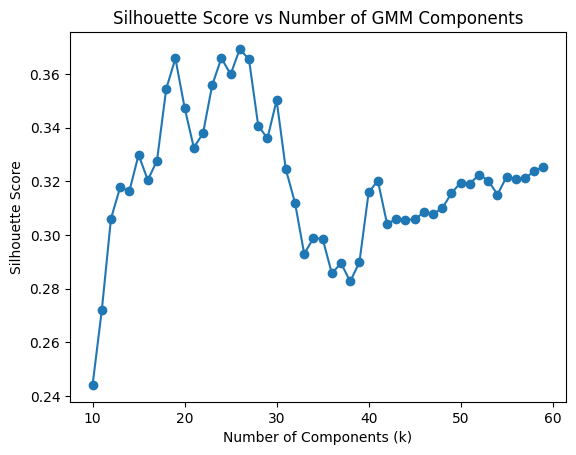

In [6]:
import matplotlib.pyplot as plt

plt.plot(k_values, scores, marker='o')
plt.xlabel('Number of Components (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of GMM Components')
plt.show()

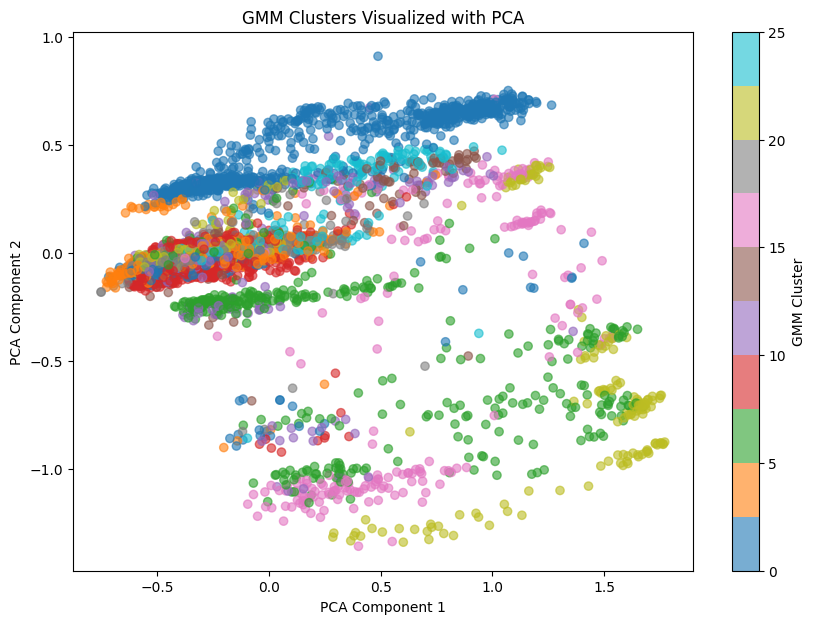

In [7]:
from sklearn.decomposition import PCA

# Reduce features to 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# Add PCA coordinates to dataframe
songs_gmm['pca1'] = X_pca[:, 0]
songs_gmm['pca2'] = X_pca[:, 1]

# Plot clusters
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    songs_gmm['pca1'],
    songs_gmm['pca2'],
    c=songs_gmm['gmm_cluster'],
    cmap='tab10',
    alpha=0.6
)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('GMM Clusters Visualized with PCA')
plt.colorbar(scatter, label='GMM Cluster')
plt.show()

When looking at the visualization of the GMM clusters using CPA, we can see a 

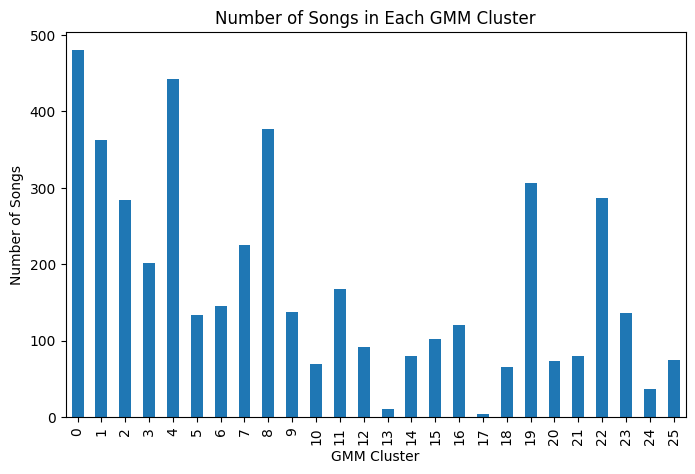

In [8]:
cluster_counts = songs_gmm['gmm_cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
cluster_counts.plot(kind='bar')
plt.xlabel('GMM Cluster')
plt.ylabel('Number of Songs')
plt.title('Number of Songs in Each GMM Cluster')
plt.show()